# **`Project 3: Team Mary Paley`**

### **Objective**: Understanding the relationship between diet, budget, and prices in the Uganda population through 2005-2020

#### Group Members:
> Emily Wu: wuemily@berkeley.edu <br>
> Rania Nasser: ranianasser@berkeley.edu <br>
> Jing Huang: hjing0117@berkeley.edu <br>
> Carmen Vega: carmenvega@berkeley.edu <br>
> Mario Zhao: mario.zhao@berkeley.edu <br>

### **[A]: Choice of a population, with supporting expenditure data**

In [2]:
!pip install -r requirements.txt

In [7]:
#Importing
%pip install python-gnupg
%pip install eep153_tools
%matplotlib inline
from eep153_tools.sheets import read_sheets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [42]:
#Prices
ugd_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2015-16).csv')
ugd_p = pd.pivot_table(ugd_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2015-16).csv')
ugd_x = pd.pivot_table(ugd_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd_x_long = ugd_x.stack().reset_index(name="Expenditure")
ugd_p_long = ugd_p0
ugd_c = ugd_x_long.merge(ugd_p_long, on=["j", "t", "m"], how="left")
ugd_c["Consumption"] = ugd_c["Expenditure"] / ugd_c["price"]
ugd_c = ugd_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd_z = ugd_z[ugd_z['t'] == '2015-16']
ugd_z = ugd_z.set_index(['i','t','m'])
ugd_z.fillna(0, inplace=True)
ugd_z.columns.name = 'k'

### **[B]: Nutritional content of different foods**

In [9]:
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### **[A]: Estimate demand system**

Let $y_{i}^j$ be log expenditures on food $j$ by household $i$ at a particular time.  We want to estimate a regression that takes the form
$$
      y^j_{i} = A^j(p) + \gamma_j'd_i + \beta_j w_i + \zeta^j_i.
$$
We have data on `y` (log expenditures) and `d` (household characteristics).  This leaves the rest of the elements for us to estimate.

In [48]:
import cfe

ugd_result = cfe.Regression(y=np.log(ugd_x.stack()),d=ugd_z)

In [11]:
ugd_result.predicted_expenditures()

i         t        m        j                     
H0010101  2015-16  Central  Avocado                    2120.091976
                            Beans (dry)                4134.714022
                            Beef                      12529.833925
                            Bread                      4827.659106
                            Cabbage (green)            1310.316756
                                                          ...     
H4301001  2015-16  Western  Sugar                      1934.313725
                            Sweet Bananas              1867.280816
                            Sweet Potatoes (fresh)     4926.310924
                            Tea                         276.122931
                            Tomatoes                   1399.526856
Length: 116240, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

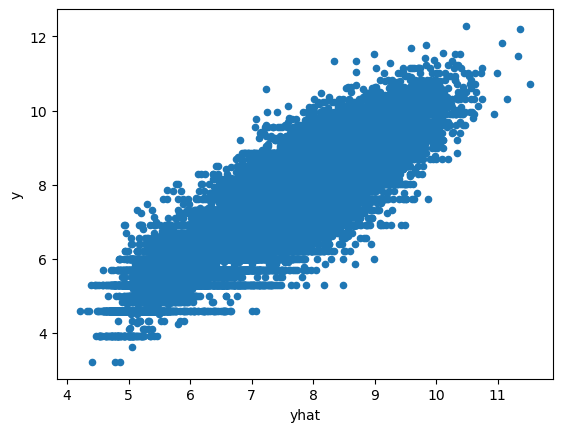

In [14]:
#Expenditures x may have duplicate columns
x1 = ugd_x0.groupby(['i','t','m','j']).sum()
#Replace zeros with missing values
x1 = x1.replace(0,np.nan)
#Take logs of expenditures; call this y
y = np.log(x1["Expenditure"])
#Create dataframe with predicted yhat values
ugd_acc = pd.DataFrame({'y':y,'yhat':ugd_result.get_predicted_log_expenditures()})
#Plot yhat vs y (predicted vs actual)
ugd_acc.plot.scatter(x='yhat',y='y')

In [15]:
ugd_result.R2(summary=True)

0.764856104196598

In [17]:
#Save result
ugd_result.to_pickle('./Uganda15-16.rgsn')
##To access result:
#import cfe
#result = cfe.regression.read_pickle('Uganda15-16.rgsn')

### Parameters

**(Relative) Income Elasticity:** $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.
Here we use a plot to visualize, with confidence intervals.

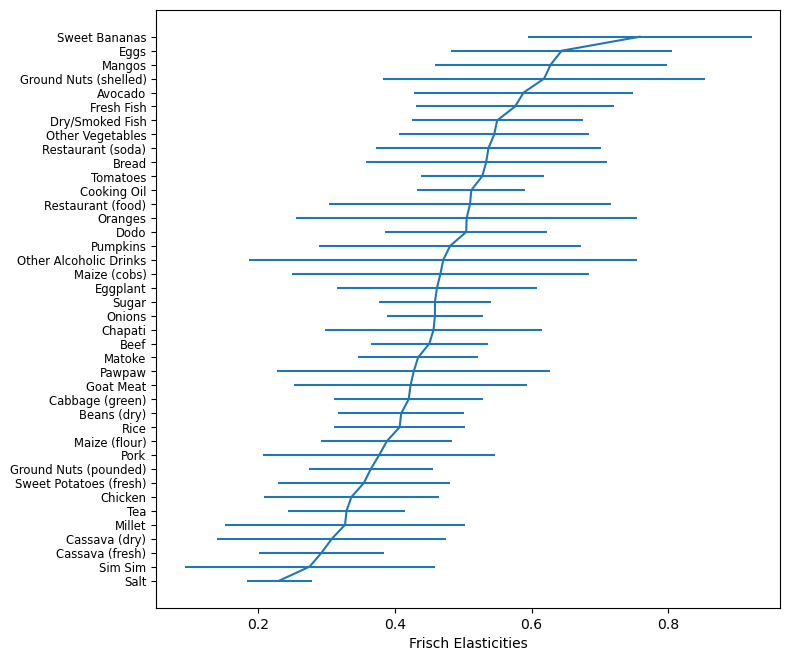

In [18]:
ax1 = ugd_result.graph_beta()

In [19]:
ugd_result.get_beta().sort_values(ascending=False)

j
Sweet Bananas             0.758181
Eggs                      0.644178
Mangos                    0.627972
Ground Nuts (shelled)     0.618427
Avocado                   0.588379
Fresh Fish                0.575933
Dry/Smoked Fish           0.549655
Other Vegetables          0.545350
Restaurant (soda)         0.536853
Bread                     0.533588
Tomatoes                  0.527785
Cooking Oil               0.511878
Restaurant (food)         0.509904
Oranges                   0.505017
Dodo                      0.504313
Pumpkins                  0.480792
Other Alcoholic Drinks    0.470761
Maize (cobs)              0.466558
Eggplant                  0.461610
Sugar                     0.458563
Onions                    0.458546
Chapati                   0.456595
Beef                      0.450475
Matoke                    0.433919
Pawpaw                    0.427537
Goat Meat                 0.422822
Cabbage (green)           0.420185
Beans (dry)               0.409169
Rice              

**Demand and Household Composition:** $\gamma_j$ parameters in the regression, which capture the effects of household composition on demand

In [20]:
ugd_result.get_gamma()

k,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Avocado,-0.017022,0.040383,0.085357,0.057376,0.033778,0.093698,0.090873,-0.056665,0.102690,0.096348,0.088200,0.114279,0.135625,0.155803,0.064484,7.110185
Beans (dry),0.035877,-0.010599,0.104012,0.050623,0.096566,0.109317,0.158134,0.015557,0.054442,0.125341,0.092897,0.077161,0.098424,0.173038,0.093793,8.187674
Beef,-0.075917,0.056709,0.044908,0.059262,0.074835,0.100295,0.128835,-0.088434,0.086130,0.037981,0.021540,0.099057,0.116606,0.150417,0.018065,9.078498
Bread,-0.258717,0.000349,0.045100,0.087147,0.121055,0.063794,0.055851,-0.059545,0.042849,0.001126,0.036063,0.110168,0.219202,0.164781,0.063769,7.959913
Cabbage (green),-0.001170,0.019499,0.034065,0.085531,0.038855,0.057547,0.100799,0.016914,-0.012753,0.068554,0.030950,0.065302,0.106563,0.119714,0.074959,7.034253
Cassava (dry),0.094600,-0.008534,0.042279,0.017159,0.052540,0.114369,0.195469,0.028261,0.145111,0.037117,0.159309,0.096261,0.058500,-0.045288,0.052256,8.433321
Cassava (fresh),-0.027513,0.037203,0.085346,0.085630,0.085075,0.118772,0.123921,-0.007042,0.131753,0.093166,0.138213,0.109007,0.034099,0.124553,0.170360,8.009837
Chapati,-0.070762,0.045395,0.097121,0.030148,0.164418,0.041021,-0.020996,-0.136423,0.051800,0.107077,-0.026025,0.161951,0.055865,-0.154211,0.005441,7.594179
Chicken,-0.214578,0.111135,-0.088050,-0.016841,0.129362,0.095046,0.173778,-0.096605,0.061147,-0.013939,0.117773,0.131648,0.213168,0.118675,-0.033599,9.515051


**Welfare:** $w_i$ parameters, which are a welfare measure for the household.

<Axes: ylabel='Density'>

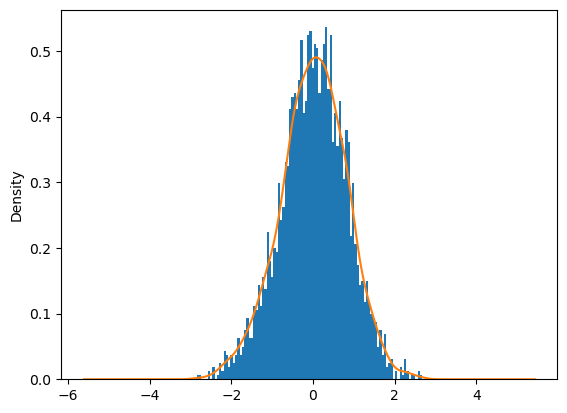

In [22]:
ax2 = ugd_result.get_w().plot.hist(bins=100,density=True)
ugd_result.get_w().plot.kde(ax=ax2)

### Demand and Utility

**Budgets:** Get food budget for all households, then find median budget

In [58]:
xhat = ugd_result.predicted_expenditures()
#Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()
#Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

**Reference Prices:** Choose reference prices.  Here we chose the year 2015 and averaged prices across markets.

In [24]:
#Prices per kilogram:
pbar = ugd_p.mean(axis=1)
pbar = pbar.reset_index(level="u", drop=True) #Reset index so that 'j' becomes a column instead of part of a MultiIndex
pbar = pbar.reindex(ugd_result.beta.index) #Only use prices for goods we can estimate
#Replace missing prices with 1 (this is because they're best measured in expenditures)
pbar = pbar.replace(np.nan,1)
#Define a function to change a single price in the vector $p$:
def my_prices(p0,j,p=pbar):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

**Demand as a function of prices:** Demand schedules for households with different budgets

Text(0.5, 0, 'Quantities of Beef Demanded')

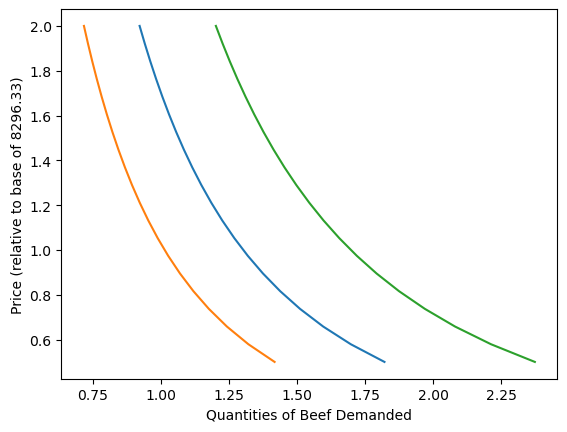

In [26]:
use = 'Beef'  #Good we want demand curve for

#Vary prices from 50% to 200% of reference.
scale = np.linspace(.5,2,20)

#Demand for Millet for household at median budget
plt.plot([ugd_result.demands(xref,my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 25% percentile
plt.plot([ugd_result.demands(xbar.quantile(0.25),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 75% percentile
plt.plot([ugd_result.demands(xbar.quantile(0.75),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded")

**Engel Curves:** Tracing how demand changes with budget

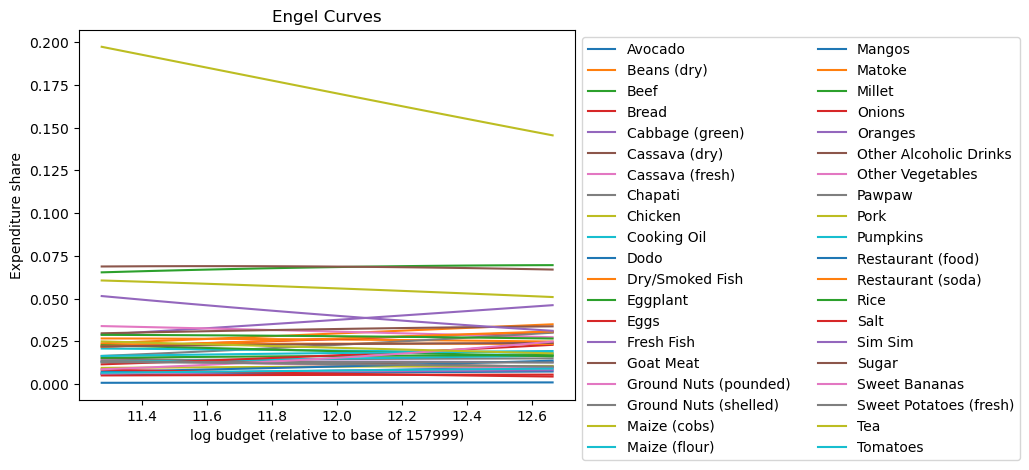

In [35]:
fig,ax = plt.subplots()

ax.plot(np.log(scale*xref),[ugd_result.expenditures(s*xref,pbar)/(s*xref) for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')
ax.legend(ugd_result.expenditures(xref,pbar).index.tolist(), loc="upper left", bbox_to_anchor=(1, 1), ncol=2)

**Indirect Utility Function:**

Text(0.5, 1.0, 'Indirect Utility Function')

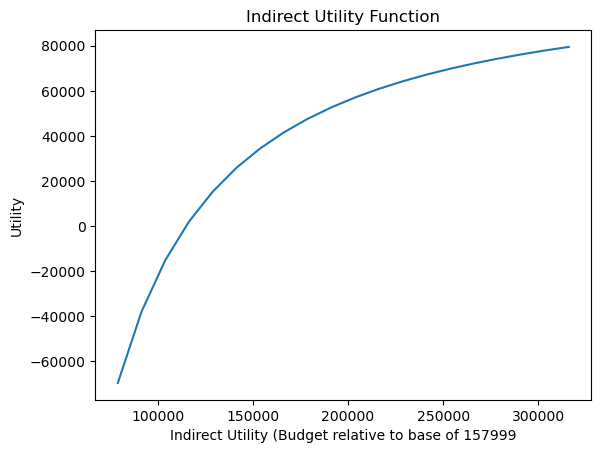

In [37]:
fig,ax = plt.subplots()

ax.plot(scale*xref,[ugd_result.indirect_utility(s*xref,pbar) for s in scale])
ax.set_xlabel(f'Indirect Utility (Budget relative to base of {xref:.0f}')
ax.set_ylabel(f'Utility')
ax.set_title('Indirect Utility Function')

### **[B]: Nutritional adequacy of diet**

In [38]:
#Get result saved above
ugd_result = cfe.read_pickle('Uganda15-16.rgsn')
#Quantities in kg: expenditures divided by prices/kg
qhat = (xhat.unstack('j')/ugd_p.reset_index(drop=True, level="u").transpose()).dropna(how='all')
#Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

In [39]:
#Coluns of qhat to match fct
use = ugd_fct.index.intersection(qhat.columns)

nutrients = qhat[use]@ugd_fct.loc[use,:]
nutrients.mean()    # NB: Nutrients are for past /week/ for entire household

n
Energy          134912.510591
Protein           5025.547146
Fiber             2094.627068
Folate           23919.922046
Calcium          24522.759821
Carbohydrate     22236.733518
Iron               833.341769
Niacin            1307.855763
Riboflavin          80.043776
Thiamin            109.335500
Vitamin A        26699.803576
Vitamin B-12       241.053081
Vitamin B-6        204.924341
Vitamin C        11481.060469
Zinc               540.194732
Magnesium            0.000000
Phosphorus           0.000000
Potassium            5.706786
Vitamin E            0.000000
Vitamin K            0.000000
dtype: float64

In [40]:
#Obtain recommended daily intake
ugd_z = ugd_z[ugd_rdi.columns.tolist()]
hh_rdi = ugd_z@ugd_rdi.T
#Make this a recommended WEEKLY intake
hh_rwi = hh_rdi*7
# Match up nutrient names
use_nutrients = nutrients.columns.intersection(hh_rwi.columns)
nutrient_ratio = (nutrients[use_nutrients]/hh_rwi[use_nutrients]).dropna()
#Display
nutrient_ratio

,,n,Energy,Protein,Fiber,Folate,Calcium,Carbohydrate,Iron,Niacin,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc,Magnesium,Phosphorus,Potassium,Vitamin E,Vitamin K
i,t,m,,,,,,,,,,,,,,,,,,,,
H0010101,2015-16,Central,2.820302,5.223071,2.894928,2.804160,1.150535,6.473210,4.806462,4.294490,3.149916,4.232854,1.152132,5.840257,6.783888,4.423265,2.658277,0.0,0.0,0.000054,0.0,0.0
H0010201,2015-16,Central,1.894441,3.771548,2.010060,1.987834,0.694726,3.824008,2.802434,2.939268,2.106037,3.157327,0.919978,3.380399,4.803211,3.638222,1.984104,0.0,0.0,0.000051,0.0,0.0
H0010401,2015-16,Central,0.973940,2.094081,1.066412,0.901529,0.278531,1.470912,1.011250,1.411851,1.019162,1.459266,0.534081,1.509706,2.286529,2.113987,1.135079,0.0,0.0,0.000023,0.0,0.0
H0020801,2015-16,Central,2.643759,4.657844,2.771232,2.440763,0.954654,5.666282,3.385430,3.799566,2.771867,3.636616,1.091687,5.046534,5.542853,3.967126,2.268445,0.0,0.0,0.000047,0.0,0.0
H0020901,2015-16,Central,2.210524,4.185790,2.255724,2.040220,0.755995,4.585101,2.540402,3.279087,2.374437,3.190704,0.930217,4.193970,4.966009,3.584808,2.086584,0.0,0.0,0.000043,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H4300701,2015-16,Western,2.529929,4.868644,2.756568,2.534270,0.712516,5.423277,3.535197,3.813474,2.711165,3.828312,1.066010,5.547272,6.823622,5.553610,2.144750,0.0,0.0,0.000046,0.0,0.0
H4300801,2015-16,Western,2.094142,4.482573,2.378425,2.164383,0.470480,3.571401,2.181360,3.143270,2.233502,3.303241,1.041566,4.019150,5.938592,6.016346,1.981191,0.0,0.0,0.000038,0.0,0.0
H4300901,2015-16,Western,1.946322,3.124021,2.398836,1.810456,0.507829,4.466682,1.756425,2.647904,2.022540,2.795365,0.989147,2.886214,4.960689,4.393300,1.726681,0.0,0.0,0.000029,0.0,0.0


<Axes: >

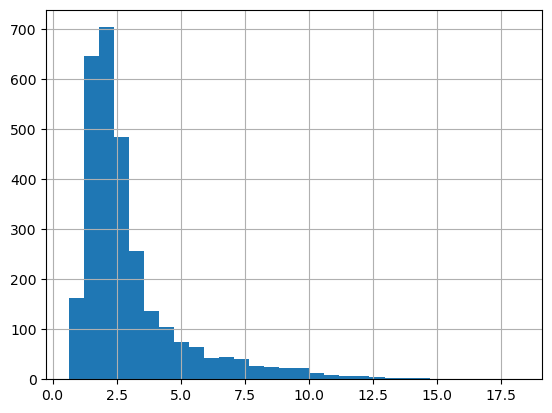

In [59]:
#Plot nutrient ratio for specific nutrient
%matplotlib inline
nutrient_ratio['Energy'].hist(bins=30)

### **[C]: Counterfactual experiments**